<a href="https://colab.research.google.com/github/cs24dse009-ops/CSL701-CS34_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Ayush Mahesh Naik RollNo: CS34

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [2]:
# ============================================================
# Task 1: Environment Setup and Dataset Acquisition
# ============================================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

# ------------------------------------------------------------
# 2. Upload dataset
# ------------------------------------------------------------

from google.colab import files

uploaded = files.upload()

# ------------------------------------------------------------
# 3. Check uploaded filename
# ------------------------------------------------------------

print("Uploaded file:")
print(list(uploaded.keys()))

# ------------------------------------------------------------
# 4. Get the actual uploaded filename
# ------------------------------------------------------------

filename = list(uploaded.keys())[0]

# ------------------------------------------------------------
# 5. Define column names
# ------------------------------------------------------------

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# ------------------------------------------------------------
# 6. Load dataset
# ------------------------------------------------------------

df = pd.read_csv(
    filename,
    header=None,
    names=columns
)

# ------------------------------------------------------------
# 7. First five records
# ------------------------------------------------------------

print("\nFirst Five Records:")
print(df.head())

# ------------------------------------------------------------
# 8. Dataset shape
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 9. Data types
# ------------------------------------------------------------

print("\nData Types:")
print(df.dtypes)

# ------------------------------------------------------------
# 10. Descriptive statistics
# ------------------------------------------------------------

print("\nDescriptive Statistics:")
print(df.describe())

Saving diabetes.csv to diabetes (1).csv
Uploaded file:
['diabetes (1).csv']

First Five Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35    169.5  33.6   
2            1       85             66             29    102.5  26.6   
3            8      183             64             32    169.5  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  

Dataset Shape:
(769, 9)

Data Types:
Pregnancies                 object
Glucose                     object
BloodPressure               object
SkinThickness               object
Insulin                     

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Unique Outcome values:
['Outcome' '1' '0']

Class Balance:
                  Count  Percentage
Non-Diabetic (0)    500        65.1
Diabetic (1)        268        34.9


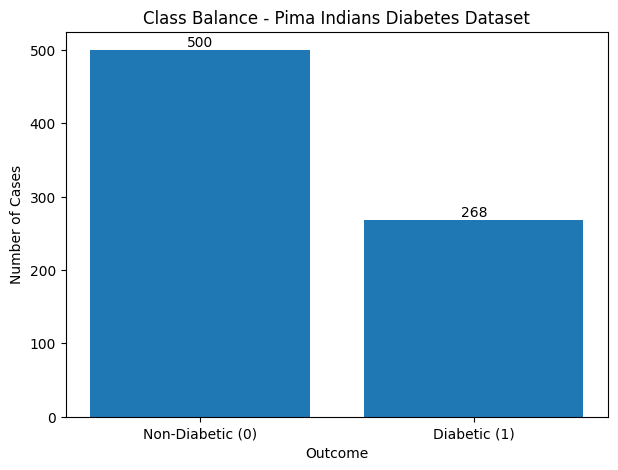

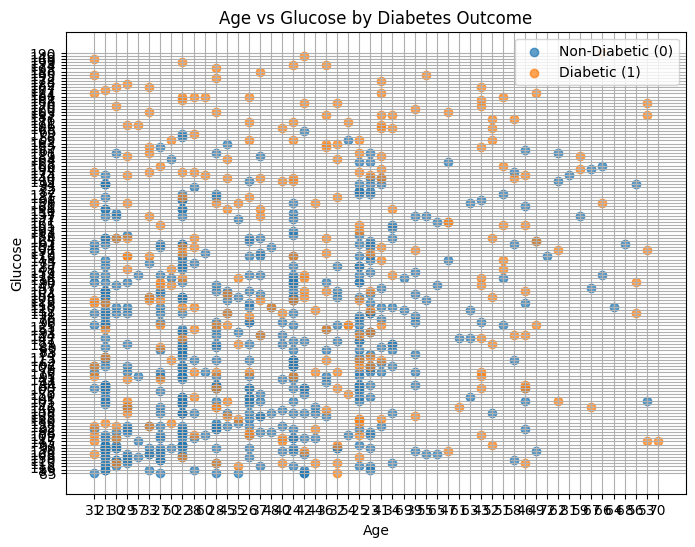


Explanation:

A simple linear decision boundary is not sufficient because
diabetic and non-diabetic patients overlap in the Age-Glucose
feature space.

Patients with similar Age or Glucose values can have different
diabetes outcomes. Therefore, the relationship between the
features and diabetes is not perfectly linear.

Decision Trees and Bagging can handle these non-linear and
complex relationships more effectively.



In [4]:
# ============================================================
# Task 2: Exploratory Data Analysis (EDA)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Check Outcome values
# ------------------------------------------------------------

print("Unique Outcome values:")
print(df["Outcome"].unique())

# Convert Outcome to numeric
df["Outcome"] = pd.to_numeric(df["Outcome"], errors="coerce")

# Remove rows with invalid Outcome values
df = df[df["Outcome"].isin([0, 1])].copy()

# ------------------------------------------------------------
# 2. Calculate Count and Percentage
# ------------------------------------------------------------

class_count = df["Outcome"].value_counts().reindex(
    [0, 1],
    fill_value=0
)

class_percentage = (
    class_count / class_count.sum() * 100
)

# Create summary table
class_balance = pd.DataFrame({
    "Count": class_count,
    "Percentage": class_percentage.round(2)
})

class_balance.index = [
    "Non-Diabetic (0)",
    "Diabetic (1)"
]

print("\nClass Balance:")
print(class_balance)

# ------------------------------------------------------------
# 3. Bar Chart - Class Balance
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    class_count.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Cases")
plt.title("Class Balance - Pima Indians Diabetes Dataset")

# Display count on bars
for i, value in enumerate(class_count.values):
    plt.text(
        i,
        value + 5,
        str(value),
        ha="center"
    )

plt.show()

# ------------------------------------------------------------
# 4. Scatter Plot - Age vs Glucose
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.7
)

plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    label="Diabetic (1)",
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose by Diabetes Outcome")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 5. Explanation
# ------------------------------------------------------------

print("\nExplanation:")
print("""
A simple linear decision boundary is not sufficient because
diabetic and non-diabetic patients overlap in the Age-Glucose
feature space.

Patients with similar Age or Glucose values can have different
diabetes outcomes. Therefore, the relationship between the
features and diabetes is not perfectly linear.

Decision Trees and Bagging can handle these non-linear and
complex relationships more effectively.
""")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [6]:
# ============================================================
# Task 3: Preprocessing and Handling Missing Values
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Features where 0 is physically impossible
# ------------------------------------------------------------

invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# ------------------------------------------------------------
# 2. Convert all columns to numeric
# ------------------------------------------------------------

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# ------------------------------------------------------------
# 3. Replace invalid 0 values with NaN
# ------------------------------------------------------------

df[invalid_features] = df[invalid_features].replace(0, np.nan)

# ------------------------------------------------------------
# 4. Display missing values before imputation
# ------------------------------------------------------------

print("Missing values before imputation:")
print(df[invalid_features].isnull().sum())

# ------------------------------------------------------------
# 5. Replace NaN with median of each feature
# ------------------------------------------------------------

for column in invalid_features:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

# ------------------------------------------------------------
# 6. Display missing values after imputation
# ------------------------------------------------------------

print("\nMissing values after imputation:")
print(df[invalid_features].isnull().sum())

# ------------------------------------------------------------
# 7. Check data types
# ------------------------------------------------------------

print("\nData Types after preprocessing:")
print(df.dtypes)

# ------------------------------------------------------------
# 8. Display first five records
# ------------------------------------------------------------

print("\nFirst five records after preprocessing:")
print(df.head())

# ------------------------------------------------------------
# 9. Dataset shape
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

Missing values before imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Data Types after preprocessing:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                     float64
dtype: object

First five records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1            6      148           72.0             35    169.5  33.6   
2            1       85           66.0             29    102.5  26.6   
3            8      183           64.0             32    169.5  23.3   
4            1  

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [7]:
# ============================================================
# Task 4: Stratified Train-Test Splitting
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Separate Features (X) and Target (y)
# ------------------------------------------------------------

# First 8 columns = features
X = df.iloc[:, :8]

# 9th column = target
y = df.iloc[:, 8]

# ------------------------------------------------------------
# 2. Split into 80% Training and 20% Testing
#    Using stratified sampling
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 3. Display shapes
# ------------------------------------------------------------

print("Original Dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTraining Data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting Data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# ------------------------------------------------------------
# 4. Check class proportions
# ------------------------------------------------------------

print("\nOriginal Class Proportion:")
print(y.value_counts(normalize=True).sort_index() * 100)

print("\nTraining Class Proportion:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTesting Class Proportion:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Original Dataset:
X shape: (768, 8)
y shape: (768,)

Training Data:
X_train shape: (614, 8)
y_train shape: (614,)

Testing Data:
X_test shape: (154, 8)
y_test shape: (154,)

Original Class Proportion:
Outcome
0.0    65.104167
1.0    34.895833
Name: proportion, dtype: float64

Training Class Proportion:
Outcome
0.0    65.14658
1.0    34.85342
Name: proportion, dtype: float64

Testing Class Proportion:
Outcome
0.0    64.935065
1.0    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [8]:
# ============================================================
# Task 5: Custom Bootstrap Sampling Function
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Custom Bootstrap Sampling Function
# ------------------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample using sampling with replacement.

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        indices      : Original row indices selected
    """

    # Number of training samples
    N = len(X)

    # Randomly select N indices WITH replacement
    indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices].copy()
    y_bootstrap = y.iloc[indices].copy()

    return X_bootstrap, y_bootstrap, indices


# ------------------------------------------------------------
# 2. Generate Bootstrap Sample
# ------------------------------------------------------------

np.random.seed(42)

X_bootstrap, y_bootstrap, selected_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# ------------------------------------------------------------
# 3. Display Bootstrap Sample Size
# ------------------------------------------------------------

print("Original Training Set Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_bootstrap))

# ------------------------------------------------------------
# 4. Display selected indices
# ------------------------------------------------------------

print("\nFirst 20 Selected Original Indices:")
print(selected_indices[:20])

# ------------------------------------------------------------
# 5. Find duplicated indices
# ------------------------------------------------------------

unique_indices, counts = np.unique(
    selected_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nDuplicated Original Indices:")
print(duplicated_indices[:20])

print("Number of duplicated indices:",
      len(duplicated_indices))

# ------------------------------------------------------------
# 6. Find OOB (Out-of-Bag) indices
# ------------------------------------------------------------

all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nOOB (Out-of-Bag) Indices:")
print(oob_indices[:20])

print("Number of OOB samples:",
      len(oob_indices))

# ------------------------------------------------------------
# 7. Verification
# ------------------------------------------------------------

print("\n================ VERIFICATION ================")

if len(X_bootstrap) == len(X_train):
    print("✓ Bootstrap X has the same size as training X")

if len(y_bootstrap) == len(y_train):
    print("✓ Bootstrap y has the same size as training y")

if len(duplicated_indices) > 0:
    print("✓ Duplicate rows are present")

if len(oob_indices) > 0:
    print("✓ OOB samples are present")

print("\nBootstrap sampling completed successfully.")

Original Training Set Size: 614
Bootstrap Sample Size: 614

First 20 Selected Original Indices:
[102 435 270 106  71  20 121 466 214 330 458  87 372  99 130 308 343 491
 413 385]

Duplicated Original Indices:
[ 1  4  8 11 14 20 21 27 32 34 35 36 38 40 46 52 53 57 62 64]
Number of duplicated indices: 164

OOB (Out-of-Bag) Indices:
[ 2  3  5  6 10 12 23 25 29 30 31 33 39 43 44 49 51 54 55 56]
Number of OOB samples: 237

================ VERIFICATION ================
✓ Bootstrap X has the same size as training X
✓ Bootstrap y has the same size as training y
✓ Duplicate rows are present
✓ OOB samples are present

Bootstrap sampling completed successfully.


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [9]:
# ============================================================
# Task 6: Growing the Ensemble of Base Classifiers
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------------------------
# 1. Set number of bootstrap iterations
# ------------------------------------------------------------

B = 50

# Empty list to store trained Decision Trees
ensemble = []

# ------------------------------------------------------------
# 2. Train B Decision Trees
# ------------------------------------------------------------

np.random.seed(42)

for b in range(B):

    # Generate a bootstrap training sample
    X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the Decision Tree
    model.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add trained model to ensemble
    ensemble.append(model)

# ------------------------------------------------------------
# 3. Verify the ensemble
# ------------------------------------------------------------

print("Number of Decision Trees trained:", len(ensemble))

print("\nExpected Number of Trees:", B)

if len(ensemble) == B:
    print("✓ Ensemble successfully contains 50 Decision Trees.")
else:
    print("✗ Ensemble size is incorrect.")

Number of Decision Trees trained: 50

Expected Number of Trees: 50
✓ Ensemble successfully contains 50 Decision Trees.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [10]:
# Task 7: Implementing Aggregation (Majority Voting) from Scratch

import numpy as np

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting
    from all decision trees in the ensemble.
    """

    final_predictions = []

    # Process each test sample
    for i in range(len(X_test)):

        votes = []

        # Get prediction from every tree
        for tree in ensemble:
            prediction = tree.predict(X_test.iloc[[i]])[0]
            votes.append(prediction)

        # Count votes for each class
        count_0 = votes.count(0)
        count_1 = votes.count(1)

        # Majority voting
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Generate final Bagging predictions
y_pred_bagging = custom_bagging_predict(ensemble, X_test)


# Display results
print("Number of Decision Trees:", len(ensemble))
print("Number of Test Samples:", len(X_test))

print("\nFirst 20 Bagging Predictions:")
print(y_pred_bagging[:20])

print("\nUnique Predicted Classes:")
print(np.unique(y_pred_bagging))

# Verification
if np.all(np.isin(y_pred_bagging, [0, 1])):
    print("\n✓ All predictions are either 0 or 1.")
else:
    print("\n✗ Invalid prediction found.")

print("\nMajority voting completed successfully.")

Number of Decision Trees: 50
Number of Test Samples: 154

First 20 Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]

Unique Predicted Classes:
[0 1]

✓ All predictions are either 0 or 1.

Majority voting completed successfully.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

CONFUSION MATRIX - SINGLE DECISION TREE
[[87 13]
 [16 38]]

CONFUSION MATRIX - BAGGING
[[90 10]
 [11 43]]

SINGLE DECISION TREE vs. BAGGING PERFORMANCE
Metric                  Single Tree             Bagging
-------------------------------------------------------
Accuracy                     0.8117              0.8636
Precision                    0.7451              0.8113
Recall                       0.7037              0.7963
F1-Score                     0.7238              0.8037


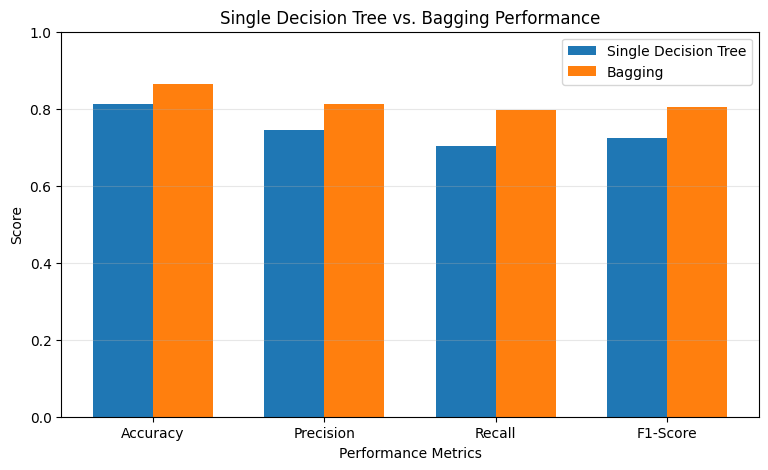


Conclusion:
✓ Bagging achieved higher accuracy than the single Decision Tree.
Bagging combines multiple fully grown Decision Trees
using majority voting, which generally helps reduce
variance and provides more stable predictions.


In [11]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# 1. Train a Single Fully Grown Decision Tree
# --------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on original, non-resampled training data
single_tree.fit(X_train, y_train)

# --------------------------------------------------
# 2. Predictions
# --------------------------------------------------

# Single Decision Tree prediction
y_pred_single = single_tree.predict(X_test)

# Bagging prediction using custom majority voting
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

# --------------------------------------------------
# 3. Confusion Matrices
# --------------------------------------------------

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("=" * 55)
print("CONFUSION MATRIX - SINGLE DECISION TREE")
print("=" * 55)
print(cm_single)

print("\n" + "=" * 55)
print("CONFUSION MATRIX - BAGGING")
print("=" * 55)
print(cm_bagging)

# --------------------------------------------------
# 4. Calculate Performance Metrics
# --------------------------------------------------

single_accuracy = accuracy_score(y_test, y_pred_single)
single_precision = precision_score(y_test, y_pred_single, zero_division=0)
single_recall = recall_score(y_test, y_pred_single, zero_division=0)
single_f1 = f1_score(y_test, y_pred_single, zero_division=0)

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging, zero_division=0)
bagging_recall = recall_score(y_test, y_pred_bagging, zero_division=0)
bagging_f1 = f1_score(y_test, y_pred_bagging, zero_division=0)

# --------------------------------------------------
# 5. Print Performance Comparison
# --------------------------------------------------

print("\n" + "=" * 75)
print("SINGLE DECISION TREE vs. BAGGING PERFORMANCE")
print("=" * 75)

print(f"{'Metric':<15}{'Single Tree':>20}{'Bagging':>20}")
print("-" * 55)

print(f"{'Accuracy':<15}{single_accuracy:>20.4f}{bagging_accuracy:>20.4f}")
print(f"{'Precision':<15}{single_precision:>20.4f}{bagging_precision:>20.4f}")
print(f"{'Recall':<15}{single_recall:>20.4f}{bagging_recall:>20.4f}")
print(f"{'F1-Score':<15}{single_f1:>20.4f}{bagging_f1:>20.4f}")

# --------------------------------------------------
# 6. Comparison Bar Chart
# --------------------------------------------------

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

single_scores = [
    single_accuracy,
    single_precision,
    single_recall,
    single_f1
]

bagging_scores = [
    bagging_accuracy,
    bagging_precision,
    bagging_recall,
    bagging_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, single_scores, width, label="Single Decision Tree")
plt.bar(x + width/2, bagging_scores, width, label="Bagging")

plt.xlabel("Performance Metrics")
plt.ylabel("Score")
plt.title("Single Decision Tree vs. Bagging Performance")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# --------------------------------------------------
# 7. Conclusion
# --------------------------------------------------

print("\nConclusion:")
if bagging_accuracy > single_accuracy:
    print("✓ Bagging achieved higher accuracy than the single Decision Tree.")
elif bagging_accuracy < single_accuracy:
    print("✓ Single Decision Tree achieved higher accuracy in this split.")
else:
    print("✓ Both models achieved the same accuracy.")

print("Bagging combines multiple fully grown Decision Trees")
print("using majority voting, which generally helps reduce")
print("variance and provides more stable predictions.")

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

ROC-AUC ANALYSIS
Single Decision Tree AUC : 0.7869
Bagging Model AUC        : 0.9506

AUC Improvement:
0.1637


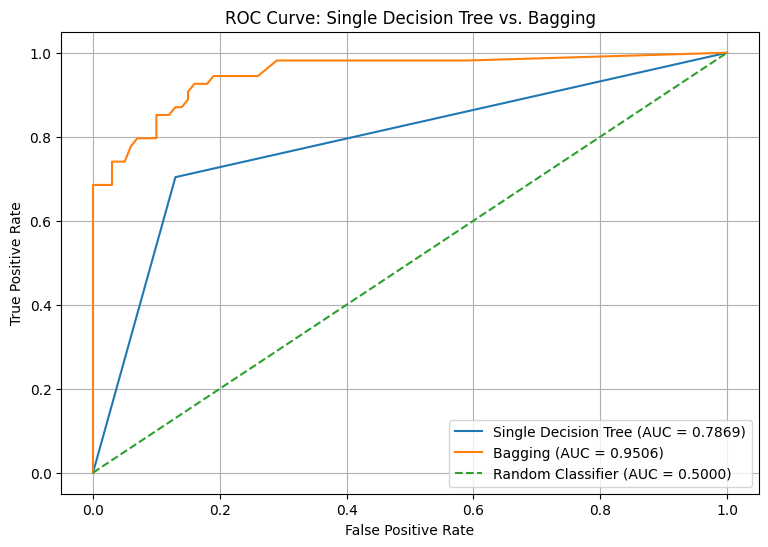


Conclusion:
✓ Bagging has a higher AUC than the Single Decision Tree.
✓ This indicates better classification performance across
  different probability thresholds.


In [12]:
# Task 9: ROC-AUC Analysis and Curve Visualization

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# --------------------------------------------------
# 1. Train Single Fully Grown Decision Tree
# --------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

# --------------------------------------------------
# 2. Predicted Probabilities - Single Decision Tree
# --------------------------------------------------

single_probabilities = single_tree.predict_proba(X_test)[:, 1]

# --------------------------------------------------
# 3. Predicted Probabilities - Bagging
#    Average probabilities from all 50 trees
# --------------------------------------------------

bagging_probabilities = []

for tree in ensemble:
    probabilities = tree.predict_proba(X_test)[:, 1]
    bagging_probabilities.append(probabilities)

# Convert to NumPy array
bagging_probabilities = np.array(bagging_probabilities)

# Average probability across all trees
bagging_probabilities = np.mean(bagging_probabilities, axis=0)

# --------------------------------------------------
# 4. Calculate ROC Curve
# --------------------------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    single_probabilities
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    bagging_probabilities
)

# --------------------------------------------------
# 5. Calculate AUC
# --------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    single_probabilities
)

auc_bagging = roc_auc_score(
    y_test,
    bagging_probabilities
)

# --------------------------------------------------
# 6. Print AUC Results
# --------------------------------------------------

print("=" * 60)
print("ROC-AUC ANALYSIS")
print("=" * 60)

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Bagging Model AUC        : {auc_bagging:.4f}")

print("\nAUC Improvement:")
print(f"{(auc_bagging - auc_single):.4f}")

# --------------------------------------------------
# 7. Plot ROC Curves
# --------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.4f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Bagging (AUC = {auc_bagging:.4f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs. Bagging")
plt.legend()
plt.grid(True)

plt.show()

# --------------------------------------------------
# 8. Conclusion
# --------------------------------------------------

print("\nConclusion:")

if auc_bagging > auc_single:
    print("✓ Bagging has a higher AUC than the Single Decision Tree.")
    print("✓ This indicates better classification performance across")
    print("  different probability thresholds.")
elif auc_bagging < auc_single:
    print("✓ Single Decision Tree has a higher AUC for this split.")
    print("  Performance can vary depending on the bootstrap samples.")
else:
    print("✓ Both models have the same AUC.")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [14]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


# =========================================================
# CUSTOM BAGGING CLASSIFIER
# =========================================================

class CustomBagging:
    def __init__(self, n_estimators=50, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        np.random.seed(self.random_state)

        self.models = []

        n_samples = len(X)

        for i in range(self.n_estimators):

            # Bootstrap sampling
            indices = np.random.choice(
                n_samples,
                size=n_samples,
                replace=True
            )

            X_bootstrap = X.iloc[indices] if hasattr(X, "iloc") else X[indices]
            y_bootstrap = y.iloc[indices] if hasattr(y, "iloc") else y[indices]

            # Decision Tree
            tree = DecisionTreeClassifier(
                max_depth=None,
                random_state=self.random_state + i
            )

            tree.fit(X_bootstrap, y_bootstrap)

            self.models.append(tree)

        return self

    def predict(self, X):

        predictions = []

        for tree in self.models:
            predictions.append(tree.predict(X))

        predictions = np.array(predictions)

        # Majority voting
        final_predictions = []

        for i in range(predictions.shape[1]):
            values, counts = np.unique(
                predictions[:, i],
                return_counts=True
            )

            final_predictions.append(values[np.argmax(counts)])

        return np.array(final_predictions)


# =========================================================
# 1. CUSTOM BAGGING
# =========================================================

custom_bagging = CustomBagging(
    n_estimators=50,
    random_state=42
)

custom_bagging.fit(X_train, y_train)

y_pred_custom = custom_bagging.predict(X_test)

custom_accuracy = accuracy_score(
    y_test,
    y_pred_custom
)

custom_cm = confusion_matrix(
    y_test,
    y_pred_custom
)


# =========================================================
# 2. SCIKIT-LEARN BAGGING CLASSIFIER
# =========================================================

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

sklearn_bagging.fit(X_train, y_train)

y_pred_sklearn = sklearn_bagging.predict(X_test)

sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

sklearn_cm = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# =========================================================
# 3. DISPLAY RESULTS
# =========================================================

print("========== TASK 10: VALIDATION ==========\n")

print("CUSTOM BAGGING CLASSIFIER")
print("--------------------------------")
print("Number of Trees:", 50)
print("Test Accuracy:", custom_accuracy)

print("\nConfusion Matrix:")
print(custom_cm)


print("\n\nSCIKIT-LEARN BAGGING CLASSIFIER")
print("--------------------------------")
print("Number of Trees:", 50)
print("Test Accuracy:", sklearn_accuracy)

print("\nConfusion Matrix:")
print(sklearn_cm)


# =========================================================
# 4. COMPARISON
# =========================================================

print("\n\n========== COMPARISON ==========")

print("Custom Bagging Accuracy     :", custom_accuracy)
print("Scikit-Learn Accuracy       :", sklearn_accuracy)

difference = abs(
    custom_accuracy - sklearn_accuracy
)

print("Accuracy Difference          :", difference)


if difference < 0.05:
    print("\nResult: Custom implementation is validated.")
    print("The accuracy is close to Scikit-Learn.")
else:
    print("\nResult: There is a noticeable difference.")
    print("Check bootstrap sampling and majority voting logic.")

========== TASK 10: VALIDATION ==========

CUSTOM BAGGING CLASSIFIER
--------------------------------
Number of Trees: 50
Test Accuracy: 0.8636363636363636

Confusion Matrix:
[[90 10]
 [11 43]]


SCIKIT-LEARN BAGGING CLASSIFIER
--------------------------------
Number of Trees: 50
Test Accuracy: 0.8831168831168831

Confusion Matrix:
[[91  9]
 [ 9 45]]


========== COMPARISON ==========
Custom Bagging Accuracy     : 0.8636363636363636
Scikit-Learn Accuracy       : 0.8831168831168831
Accuracy Difference          : 0.01948051948051943

Result: Custom implementation is validated.
The accuracy is close to Scikit-Learn.


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?